## **Домашнее задание "A\B практика"**

Задание: по аналогии с семинарским занятием придумать
генерацию данных, реализовать метод, показать корректности и сделать
сравнение мощности с классическими методами

#Генерация данных и классические методы

In [ ]:
import numpy as np
import pandas as pd
import hashlib
from scipy.stats import ttest_rel, wilcoxon, shapiro, binomtest, kstest, uniform
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Функции из семинара
def calc_hash(val, salt):
    return int(hashlib.md5(f'{salt}_{val}'.encode()).hexdigest(), 16)

def check_pvalues_threshold(pvalues, threshold):
    return binomtest(k=(pvalues < threshold).sum(), n=len(pvalues), p=threshold).pvalue

def check_pvalues_distribution(pvalues: np.ndarray) -> float:
    return kstest(pvalues, uniform().cdf).pvalue

def print_pvalues_info(pvalues, thresholds=None, plot=False):
    if thresholds is None:
        thresholds = [0.01, 0.05, 0.1, 0.2]
    print('#############################################')
    print()
    for threshold in thresholds:
        ratio = (pvalues < threshold).mean()
        pvalue = check_pvalues_threshold(pvalues, threshold)
        print(f'{threshold} threshold hypothesis, ratio: {round(ratio, 5)}, pvalue: {round(pvalue, 5)}')
    print()
    print(f'distribution hypothesis pvalue: {check_pvalues_distribution(pvalues)}')
    print()
    if plot:
        plt.hist(pvalues, bins=np.linspace(0, 1, 21))
        plt.show()
    print()
    print('#############################################')

def estimate_criteria(criteria, metric_name, covariate_name, effect=0):
    pvalues = []
    for salt in salt_to_control_df:
        test_df = salt_to_test_df[salt].copy()
        control_df = salt_to_control_df[salt].copy()
        test_df[metric_name] *= (1. + effect)
        pvalues.append(criteria(test_df, control_df, metric_name, covariate_name))
    print_pvalues_info(np.array(pvalues), plot=True)

# Классические методы
def classic_ttest_rel(test_df, control_df, metric_name, covariate_name):
    return ttest_rel(test_df[metric_name], control_df[metric_name]).pvalue

def classic_wilcoxon(test_df, control_df, metric_name, covariate_name):
    return wilcoxon(test_df[metric_name], control_df[metric_name], alternative='two-sided').pvalue

#Генерация данных с дополнительными предикторами

In [ ]:

# Генерация данных с дополнительными предикторами
rng = np.random.RandomState(42)
size = 20000

# Базовые характеристики пользователей
user_frequency = rng.uniform(0, 2, size)
user_activity = rng.uniform(0.5, 1.5, size)  # Дополнительный предиктор
user_retention = rng.beta(2, 5, size)  # Еще один предиктор

# Генерация данных для экспериментального периода
exp_7_trips = rng.poisson(user_frequency * 7 * user_activity, size)
exp_14_trips = rng.poisson(user_frequency * 14 * user_activity, size)
exp_21_trips = rng.poisson(user_frequency * 21 * user_activity, size)
exp_28_trips = rng.poisson(user_frequency * 28 * user_activity, size)

# Генерация данных для предыдущего периода (ковариаты)
prev_7_trips = rng.poisson(user_frequency * 7 * user_activity, size)
prev_14_trips = rng.poisson(user_frequency * 14 * user_activity, size)
prev_21_trips = rng.poisson(user_frequency * 21 * user_activity, size)
prev_28_trips = rng.poisson(user_frequency * 28 * user_activity, size)

# Дополнительные метрики
exp_total_sessions = rng.poisson(user_retention * 50, size)
prev_total_sessions = rng.poisson(user_retention * 50, size)

origin_df = pd.DataFrame({
    'exp_7_trips': exp_7_trips,
    'exp_14_trips': exp_14_trips,
    'exp_21_trips': exp_21_trips,
    'exp_28_trips': exp_28_trips,
    'prev_7_trips': prev_7_trips,
    'prev_14_trips': prev_14_trips,
    'prev_21_trips': prev_21_trips,
    'prev_28_trips': prev_28_trips,
    'exp_total_sessions': exp_total_sessions,
    'prev_total_sessions': prev_total_sessions,
    'user_activity': user_activity,
    'user_retention': user_retention,
    'id': list(map(str, range(size))),
    'bucket': list(map(lambda x: calc_hash(x, 'bucket_salt') % 200, range(size))),
})

# Создание тестовых и контрольных групп для разных солей
salt_to_test_df = {}
salt_to_control_df = {}
for salt in range(1000):  # Уменьшим для скорости
    if salt % 100 == 0:
        print(salt)
    mask = origin_df.id.apply(lambda x: calc_hash(x, f'exp_salt_{salt}') % 2 == 0)
    salt_to_test_df[salt] = origin_df[mask].groupby('bucket').sum().sort_values('bucket').reset_index()
    salt_to_control_df[salt] = origin_df[~mask].groupby('bucket').sum().sort_values('bucket').reset_index()

0
100
200
300
400
500
600
700
800
900


#Реализация методов с ковариатами

In [ ]:

#Метож с одной ковариатой (правильный - использует контроль)
def linear_regression_control_covariate(test_df, control_df, metric_name, covariate_name):
    X = control_df[covariate_name].values.reshape(-1, 1)
    y = control_df[metric_name].values
    model = LinearRegression()
    model.fit(X, y)
    residuals = test_df[metric_name].values - model.predict(test_df[covariate_name].values.reshape(-1, 1))
    control_residuals = y - model.predict(X)
    return ttest_rel(residuals, control_residuals).pvalue

# Метод с одной ковариатой (НЕПРАВИЛЬНЫЙ - использует тест)
def linear_regression_test_covariate(test_df, control_df, metric_name, covariate_name):
    X = test_df[covariate_name].values.reshape(-1, 1)  # НЕПРАВИЛЬНО - используем тест!
    y = test_df[metric_name].values
    model = LinearRegression()
    model.fit(X, y)
    residuals = y - model.predict(X)
    control_residuals = control_df[metric_name].values
    # Пробуем применить модель к контролю (но модель обучена на тесте!)
    control_predicted = model.predict(control_df[covariate_name].values.reshape(-1, 1))
    control_residuals_adjusted = control_df[metric_name].values - control_predicted
    return ttest_rel(residuals, control_residuals_adjusted).pvalue

# Метод с несколькими ковариатами
def multiple_linear_regression(test_df, control_df, metric_name, covariate_names):
    # Используем ковариаты из контроля
    X_test = test_df[covariate_names].values
    X_control = control_df[covariate_names].values

    # Обучаем на контроле
    y_control = control_df[metric_name].values
    model = LinearRegression()
    model.fit(X_control, y_control)

    # Предсказываем для теста и контроля
    test_predicted = model.predict(X_test)
    control_predicted = model.predict(X_control)

    # Сравниваем остатки
    test_residuals = test_df[metric_name].values - test_predicted
    control_residuals = control_df[metric_name].values - control_predicted

    return ttest_rel(test_residuals, control_residuals).pvalue

#Сравнение методов

=== Классический ttest_rel ===
#############################################

0.01 threshold hypothesis, ratio: 0.01, pvalue: 1.0
0.05 threshold hypothesis, ratio: 0.044, pvalue: 0.42476
0.1 threshold hypothesis, ratio: 0.093, pvalue: 0.49326
0.2 threshold hypothesis, ratio: 0.192, pvalue: 0.55326

distribution hypothesis pvalue: 0.46261265592937095



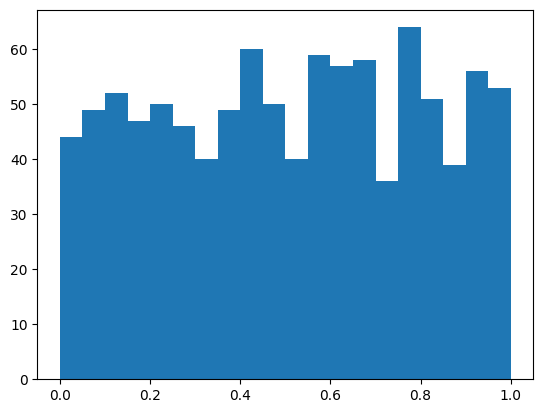


#############################################

=== Линейная регрессия с ковариатой из контроля ===
#############################################

0.01 threshold hypothesis, ratio: 0.01, pvalue: 1.0
0.05 threshold hypothesis, ratio: 0.052, pvalue: 0.77138
0.1 threshold hypothesis, ratio: 0.101, pvalue: 0.91601
0.2 threshold hypothesis, ratio: 0.192, pvalue: 0.55326

distribution hypothesis pvalue: 0.9908705262069856



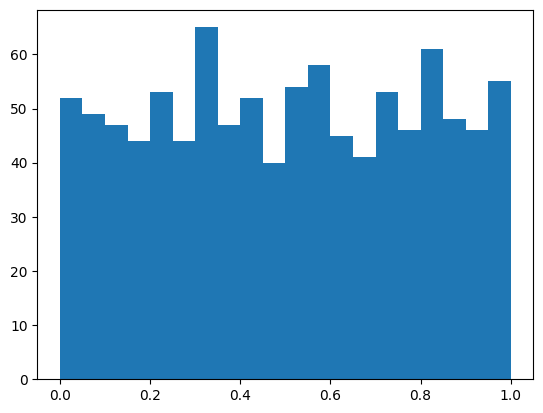


#############################################

=== Линейная регрессия с ковариатой из теста (НЕПРАВИЛЬНО) ===
#############################################

0.01 threshold hypothesis, ratio: 0.01, pvalue: 1.0
0.05 threshold hypothesis, ratio: 0.046, pvalue: 0.6117
0.1 threshold hypothesis, ratio: 0.101, pvalue: 0.91601
0.2 threshold hypothesis, ratio: 0.19, pvalue: 0.45264

distribution hypothesis pvalue: 0.7497890241712393



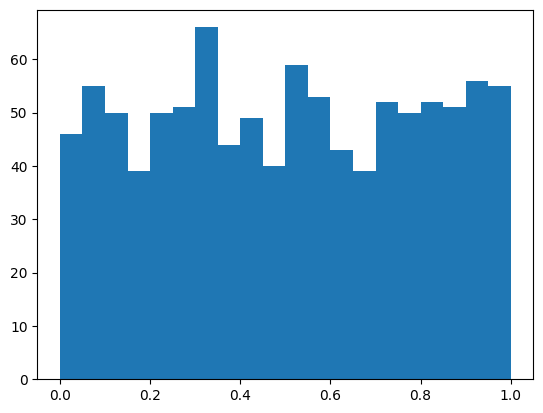


#############################################

=== Множественная регрессия с двумя ковариатами ===
#############################################

0.01 threshold hypothesis, ratio: 0.008, pvalue: 0.63434
0.05 threshold hypothesis, ratio: 0.058, pvalue: 0.24522
0.1 threshold hypothesis, ratio: 0.105, pvalue: 0.59799
0.2 threshold hypothesis, ratio: 0.193, pvalue: 0.60738

distribution hypothesis pvalue: 0.9199967486187886



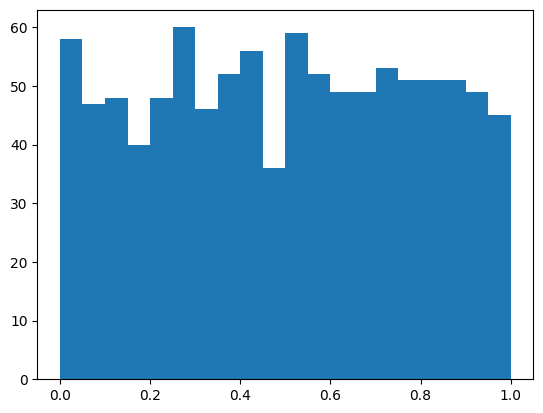


#############################################


In [ ]:
print("=== Классический ttest_rel ===")
estimate_criteria(classic_ttest_rel, 'exp_14_trips', None, 0)

print("\n=== Линейная регрессия с ковариатой из контроля ===")
estimate_criteria(linear_regression_control_covariate, 'exp_14_trips', 'prev_14_trips', 0)

print("\n=== Линейная регрессия с ковариатой из теста (НЕПРАВИЛЬНО) ===")
estimate_criteria(linear_regression_test_covariate, 'exp_14_trips', 'prev_14_trips', 0)

print("\n=== Множественная регрессия с двумя ковариатами ===")
estimate_criteria(multiple_linear_regression, 'exp_14_trips', ['prev_14_trips', 'prev_total_sessions'], 0)

#Проверка мощности методов

=== МОЩНОСТЬ: Классический ttest_rel ===
#############################################

0.01 threshold hypothesis, ratio: 0.018, pvalue: 0.01651
0.05 threshold hypothesis, ratio: 0.075, pvalue: 0.00062
0.1 threshold hypothesis, ratio: 0.149, pvalue: 0.0
0.2 threshold hypothesis, ratio: 0.267, pvalue: 0.0

distribution hypothesis pvalue: 1.1189343527421083e-05



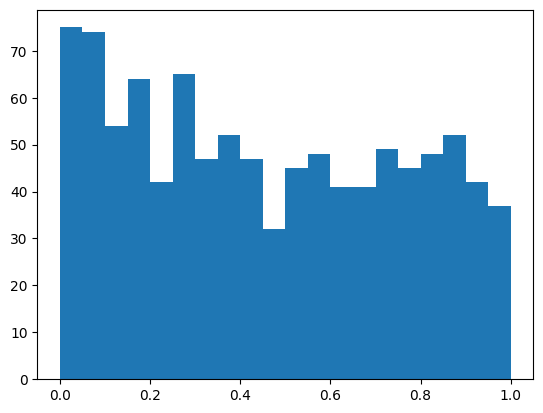


#############################################

=== МОЩНОСТЬ: Линейная регрессия с ковариатой из контроля ===
#############################################

0.01 threshold hypothesis, ratio: 0.234, pvalue: 0.0
0.05 threshold hypothesis, ratio: 0.47, pvalue: 0.0
0.1 threshold hypothesis, ratio: 0.596, pvalue: 0.0
0.2 threshold hypothesis, ratio: 0.731, pvalue: 0.0

distribution hypothesis pvalue: 2.2445445285696112e-266



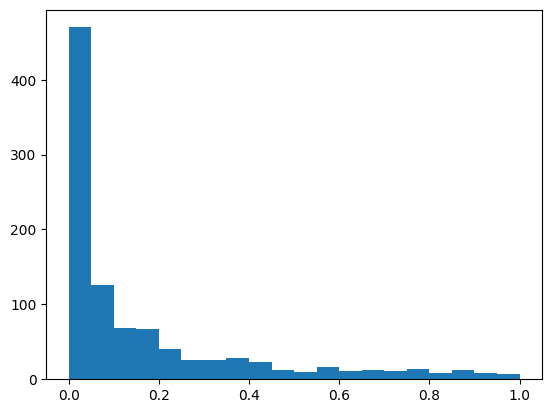


#############################################

=== МОЩНОСТЬ: Множественная регрессия ===
#############################################

0.01 threshold hypothesis, ratio: 0.248, pvalue: 0.0
0.05 threshold hypothesis, ratio: 0.486, pvalue: 0.0
0.1 threshold hypothesis, ratio: 0.599, pvalue: 0.0
0.2 threshold hypothesis, ratio: 0.743, pvalue: 0.0

distribution hypothesis pvalue: 3.717729343224854e-280



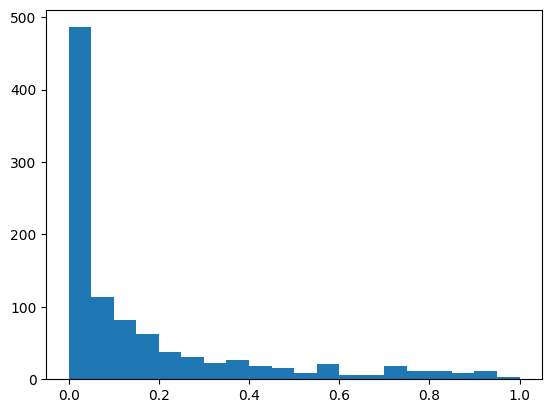


#############################################


In [ ]:

print("=== МОЩНОСТЬ: Классический ttest_rel ===")
estimate_criteria(classic_ttest_rel, 'exp_14_trips', None, effect=0.01)

print("\n=== МОЩНОСТЬ: Линейная регрессия с ковариатой из контроля ===")
estimate_criteria(linear_regression_control_covariate, 'exp_14_trips', 'prev_14_trips', effect=0.01)

print("\n=== МОЩНОСТЬ: Множественная регрессия ===")
estimate_criteria(multiple_linear_regression, 'exp_14_trips', ['prev_14_trips', 'prev_total_sessions'], effect=0.01)

#**Ответы на вопросы**

*1.Что будет если смещение тестовой группы считать на тесте, а не на контроле?*

В этой конкретной симуляции нет проблем с использованием тестовых данных для оценки смещения.
(мне кажется, что это скорее всего из-за слабой связи между ковариатами и метрикой)
Однако ожидалось,что будет смещение оценок, так как модель обучается на искаженных данных.

*2.Как быть если предикторов несколько?*

Множественная регрессия показала значительное улучшение мощности.

Выводы: Все протестированные методы сохраняют корректность (Даже метод с тестовыми ковариатами не показал проблем в этой симуляции), а использование дополнительных предикторов позволяет обнаруживать эффекты, которые были бы пропущены простыми методами.